# Eyeplan CogSci Replication

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels.formula.api as smf
import torch
import json
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

from modules import *

plt.rcParams['font.size'] = 14
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['font.family'] = 'Arial'

In [2]:
# set random seed
seed = 3
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

## Load data

In [3]:
with open('data/trials.json', 'r') as f:
    data_raw = json.load(f)

## Preprocessing

In [ ]:
from itertools import groupby

# make sure data is sorted by 'pid'
data_raw.sort(key = lambda x: x['pid'])

data = []

for pid, trials in groupby(data_raw, key = lambda x: x['pid']):
    # create recording
    data_subj = {
        'pids': [],
        'child_dicts': [],
        'parent_dicts': [],
        'root_nodes': [],
        'depths': [],
        'points': [],
        'cum_points': [],
        'fixation_seqs': [],
        'decision_seqs': [],
    }
    
    for trial in trials:
        # get child dict
        child_dict_ep = adj_list_to_child_dict(trial['graph'])

        # get parent dict
        parent_dict_ep = {v: k for k, values in child_dict_ep.items() for v in values}
        
        # get root node
        root_node_ep = trial['start']

        # get depths
        d = get_node_depths(child_dict_ep, root_node_ep)
        depths_ep = [d[k] for k in sorted(d)]

        # get points
        points_ep = trial['rewards']

        # get cumulative points
        cum_points_ep = get_cum_points(child_dict_ep, root_node_ep, points_ep)

        # extract fixation sequence without 'contains_move' == True
        fixation_seq_ep = []
        for f in trial['fixations']:
            if f['contains_move']:
                break
            fixation_seq_ep.append(f['state'])
        fixation_seq_ep = merge(fixation_seq_ep)
        
        # extract decision sequence from moves
        decision_seq_ep = [m['state'] for m in trial['moves']]
        
        if len(decision_seq_ep) == 0:
            print('dec')

        # append data
        if len(fixation_seq_ep) > 0:
            data_subj['pids'].append(pid)
            data_subj['child_dicts'].append(child_dict_ep)
            data_subj['parent_dicts'].append(parent_dict_ep)
            data_subj['root_nodes'].append(root_node_ep)
            data_subj['depths'].append(depths_ep)
            data_subj['points'].append(points_ep)
            data_subj['cum_points'].append(cum_points_ep)
            data_subj['fixation_seqs'].append(fixation_seq_ep)
            data_subj['decision_seqs'].append(decision_seq_ep)

    data.append(data_subj)

## Fixation distribution

In [ ]:
fixation_counts_by_depth = []
all_fixation_counts = []

for data_subj in data:

    fixation_counts_by_depth_subj = [[] for _ in range(6)]

    for i in range(len(data_subj['pids'])):
        depths_ep = data_subj['depths'][i]
        fixation_seq_ep = data_subj['fixation_seqs'][i]
        
        # initialize fixation count at different depths
        fixation_counts_by_depth_ep = np.zeros(max(depths_ep) + 1)

        # count fixations in the episode
        for node in fixation_seq_ep:
            fixation_counts_by_depth_ep[depths_ep[node]] += 1
        
        # compute number of nodes at each depth
        num_nodes_by_depth_ep = np.unique(depths_ep, return_counts = True)[1]

        # average counts for each depth
        for j in range(len(fixation_counts_by_depth_ep)):
            fixation_counts_by_depth_subj[j].append(fixation_counts_by_depth_ep[j] / num_nodes_by_depth_ep[j])
    
    # compute proportion
    fixation_counts_by_depth_subj = np.array([np.mean(_) for _ in fixation_counts_by_depth_subj])

    # append
    fixation_counts_by_depth.append(fixation_counts_by_depth_subj)
    all_fixation_counts.append([len(_) for _ in data_subj['fixation_seqs']])

# transform to np.array
fixation_counts_by_depth = np.array(fixation_counts_by_depth)

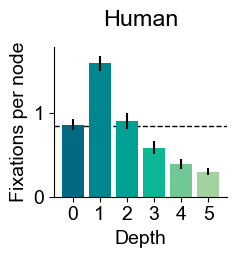

In [ ]:
# plot
colors = ['#016981', '#00868E', '#00A195', '#0BB795', '#71C897', '#A3D2A0']
means = fixation_counts_by_depth.mean(axis = 0)
errors = fixation_counts_by_depth.std(axis = 0, ddof = 1) / np.sqrt(len(data))
# plt.figure(figsize = (2.4, 2.6))
plt.figure(figsize = (2.75, 2.8))
plt.bar(x = np.arange(len(means)), height = means, color = colors, yerr = errors, capsize = 0)  # Adjust cap size for error bars)
plt.axhline(y = np.mean([np.mean(_) for _ in all_fixation_counts]) / 11, color = 'k', linestyle = '--', linewidth = 1, zorder = 0)
plt.xticks(range(len(means)))
plt.ylim((0, 1.8))
plt.xlabel('Depth')
plt.ylabel('Fixations per node')
plt.title('Human', pad = 15)
plt.tight_layout()
# plt.show()
# print(np.mean([np.mean(_) for _ in all_fixation_counts]))
plt.savefig('figures/p_fixation_by_depth.pdf', bbox_inches = 'tight')

## Local fixation proportions

In [45]:
fixation_proportions_by_type = []

for data_subj in data:

    fixation_counts_by_type_subj = {'child': 0, 'parent': 0, 'sibling': 0, 'others': 0,}

    for i in range(len(data_subj['pids'])):
        child_dict_ep = data_subj['child_dicts'][i]
        fixation_seq_ep = data_subj['fixation_seqs'][i]

        for node, node_next in list(zip(fixation_seq_ep, fixation_seq_ep[1:])):
            # count fixations by relationship
            fixation_counts_by_type_subj[relationship(child_dict_ep, node, node_next)] += 1
        
        # compute proportions
        fixation_proportions_by_type_subj = np.array(list(fixation_counts_by_type_subj.values())) / sum(fixation_counts_by_type_subj.values())

    # append
    fixation_proportions_by_type.append(fixation_proportions_by_type_subj)

# transform to np.array
fixation_proportions_by_type = np.array(fixation_proportions_by_type)

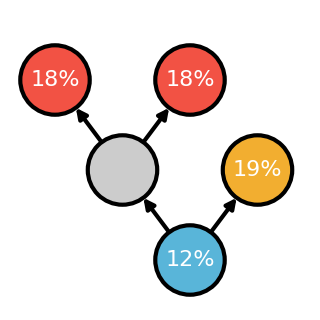

In [46]:
means = fixation_proportions_by_type.mean(axis = 0)
errors = fixation_proportions_by_type.std(axis = 0, ddof = 1) / np.sqrt(len(data))

G = nx.DiGraph()
for parent, children in {0: [1, 2], 1: [3, 4]}.items():
    for child in children:
        G.add_edge(parent, child)
pos = {
    0: [0.9, 0],
    1: [0, 0.9],
    2: [1.8, 0.9],
    3: [-0.9, 1.8],
    4: [0.9, 1.8],
}
labels = {
    0: f"{round(means[1] * 100)}%",
    1: '',
    2: f"{round(means[2] * 100)}%",
    3: f"{round(means[0] * 100 / 2)}%",
    4: f"{round(means[0] * 100 / 2)}%",
}
plt.figure(figsize = (3, 3))
nx.draw(
    G = G,
    pos = pos,
    labels = labels,
    with_labels = True,
    node_size = 2500,
    node_color = ['#59B5D9', '#CCCCCC', '#F2AE30', '#F25244', '#F25244'],
    edgecolors = 'black',
    linewidths = 3,
    width = 3,
    font_size = 16,
    arrowsize = 15,
    font_color = 'white',
    # font_weight = 'bold',
)
plt.xlim((-1.5, 2.5))
plt.ylim((-0.5, 2.5))
# plt.title('Human')
plt.tight_layout()
# plt.show()

plt.savefig('figures/p_fixation_by_type.pdf', bbox_inches = 'tight')

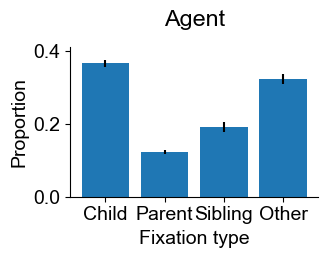

In [47]:
plt.figure(figsize = (3.5, 2.8))
plt.bar(x = np.arange(len(means)), height = means, yerr = errors, capsize = 0)
# plt.axhline(y = 1, color = 'k', linestyle = '--', linewidth = 1, zorder = 0)
plt.xticks(range(len(means)), labels = ['Child', 'Parent', 'Sibling', 'Other'])
plt.ylim((0, 0.41))
plt.xlabel('Fixation type')
plt.ylabel('Proportion')
plt.title('Agent', pad = 15)
plt.tight_layout()
# plt.show()
plt.savefig('figures/p_fixation_by_type_bar.pdf', bbox_inches = 'tight')

## Continuation policy

In [48]:
dfs = []

for pid, data_subj in enumerate(data):

    points_subj = []
    depths_subj = []
    continuations_subj = []

    for i in range(len(data_subj['pids'])):
        child_dict_ep = data_subj['child_dicts'][i]
        points_ep = data_subj['points'][i]
        depths_ep = data_subj['depths'][i]
        fixation_seq_ep = data_subj['fixation_seqs'][i]

        for node, node_next in list(zip(fixation_seq_ep, fixation_seq_ep[1:])):
            # if node is not root
            if node in child_dict_ep.keys():
                points_subj.append(points_ep[node])
                depths_subj.append(depths_ep[node])
                continuations_subj.append(int(node_next in child_dict_ep[node]))

    df_subj = pd.DataFrame({
        'points': points_subj,
        'depths': depths_subj,
        'continuations': continuations_subj,
    })
    df_subj['pid'] = pid
    dfs.append(df_subj)

df = pd.concat(dfs)

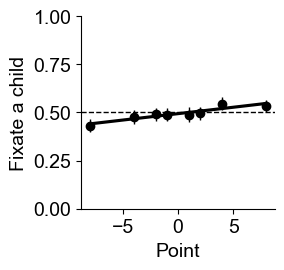

In [49]:
plt.figure(figsize = (2.5, 2.5))
df_filtered = df[df['points'] != 0]
df_grouped = df_filtered.groupby(['pid', 'points'])['continuations'].mean().reset_index()
df_summary = df_grouped.groupby(['points'])['continuations'].agg(['mean', 'std', 'count']).reset_index()
df_summary['se'] = df_summary['std'] / np.sqrt(df_summary['count'])
plt.errorbar(df_summary['points'], df_summary['mean'], yerr = df_summary['se'], fmt = 'o', color = 'black', ecolor = 'black', elinewidth = 1, capsize = 0)
sns.regplot(data = df_grouped, x = 'points', y = 'continuations', ci = False, scatter = False, color = 'k')
plt.axhline(y = 0.5, color = 'k', linestyle = '--', linewidth = 1)
plt.xticks(range(-5, 6, 5))
plt.ylim((0, 1))
plt.xlabel('Point')
plt.ylabel('Fixate a child')
# plt.tight_layout()
plt.show()

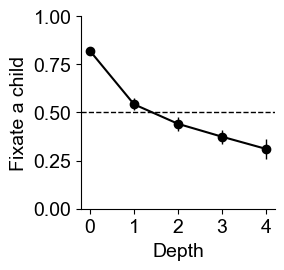

In [50]:
plt.figure(figsize = (2.5, 2.5))
df_grouped = df.groupby(['pid', 'depths'])['continuations'].mean().reset_index()
df_summary = df_grouped.groupby(['depths'])['continuations'].agg(['mean', 'std', 'count']).reset_index()
df_summary['se'] = df_summary['std'] / np.sqrt(df_summary['count'])
plt.errorbar(df_summary['depths'], df_summary['mean'], yerr = df_summary['se'], fmt = 'o-', color = 'black', ecolor = 'black', elinewidth = 1, capsize = 0)
plt.axhline(y = 0.5, color = 'k', linestyle = '--', linewidth = 1)
plt.xticks(range(0, 5, 1))
plt.ylim((0, 1))
plt.xlabel('Depth')
plt.ylabel('Fixate a child')
# plt.tight_layout()
plt.show()

## Exploitation policy

In [51]:
dfs = []

for pid, data_subj in enumerate(data):

    child1_fixation_counts_subj = []
    relative_q_values_subj = []
    q_groups_subj = []

    for i in range(len(data_subj['pids'])):
        child_dict_ep = data_subj['child_dicts'][i]
        points_ep = data_subj['points'][i]
        fixation_seq_ep = data_subj['fixation_seqs'][i]
        root_node_ep = data_subj['root_nodes'][i]

        # initialize node mask
        node_mask_ep = np.zeros((11)) # root node does not matter here
        node_mask_ep[root_node_ep] = 1.

        for node, node_next in list(zip(fixation_seq_ep, fixation_seq_ep[1:])):
            # update node mask
            node_mask_ep[node] = 1

            # if current node has children and next node is a child of current node
            if relationship(child_dict_ep, node, node_next) == 'child':
                # get children
                children = child_dict_ep[node]
                idx = np.random.randint(0, 2)
                child1, child2 = children[idx], children[1 - idx]

                # compute action values
                q_values_ep = get_q_values(child_dict_ep, points_ep * node_mask_ep)

                # append if the next fixation is on the child
                child1_fixation_counts_subj.append(int(node_next == child1))

                # append relative action value
                relative_q_values_subj.append(q_values_ep[child1] - q_values_ep[child2])

                # append group
                if node_mask_ep[child1] == 0 and node_mask_ep[child2] == 0:
                    q_groups_subj.append('none')
                elif node_mask_ep[child1] == 1 and node_mask_ep[child2] == 0:
                    q_groups_subj.append('child 1')
                elif node_mask_ep[child1] == 0 and node_mask_ep[child2] == 1:
                    q_groups_subj.append('child 2')
                elif node_mask_ep[child1] == 1 and node_mask_ep[child2] == 1:
                    q_groups_subj.append('both')
        
    df_subj = pd.DataFrame({
        'child1_fixation_counts': child1_fixation_counts_subj,
        'relative_q_values': relative_q_values_subj,
        'q_groups': q_groups_subj,
    })
    df_subj['pid'] = pid
    dfs.append(df_subj)

df = pd.concat(dfs)
df = df[(df['relative_q_values'] >= -20) & (df['relative_q_values'] <= 20)]

               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: child1_fixation_counts
No. Observations: 7608    Method:             ML                    
No. Groups:       28      Scale:              0.2487                
Min. group size:  46      Log-Likelihood:     -5502.8451            
Max. group size:  566     Converged:          No                    
Mean group size:  271.7                                             
---------------------------------------------------------------------
                       Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
---------------------------------------------------------------------
Intercept              0.507     0.006  84.122  0.000   0.495   0.519
relative_q_values      0.012     0.002   6.069  0.000   0.008   0.016
Group Var              0.000     0.000                               



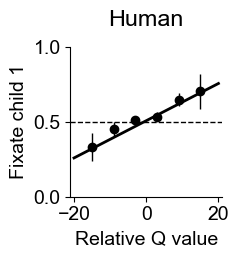

In [ ]:
plt.figure(figsize = (2.6, 2.8))

bins = [-25, -10.5, -5.5, 0, 5.5, 10.5, 25]
labels = [-15, -9, -3, 3, 9, 15]
df['group'] = pd.cut(df['relative_q_values'], bins = bins, labels = labels)
# df['group'] = df['relative_q_values']
df_grouped = df.groupby(['pid', 'group'])['child1_fixation_counts'].mean().reset_index()
df_summary = df_grouped.groupby(['group'])['child1_fixation_counts'].agg(['mean', 'std', 'count']).reset_index()
df_summary['se'] = df_summary['std'] / np.sqrt(df_summary['count'])
plt.errorbar(df_summary['group'], df_summary['mean'], yerr = df_summary['se'], fmt = 'o', color = 'black', ecolor = 'black', elinewidth = 1, capsize = 0)

model = smf.mixedlm('child1_fixation_counts ~ relative_q_values', df, groups = df['pid'])
result = model.fit(reml = False)
print(result.summary())
x_pred = np.linspace(-20, 20, 200)
df_pred = pd.DataFrame({'relative_q_values': x_pred})
df_pred["child1_fixation_counts"] = result.predict(df_pred)
plt.plot(df_pred['relative_q_values'], df_pred['child1_fixation_counts'], color = 'k', linewidth = 2)


plt.axhline(y = 0.5, color = 'k', linestyle = '--', linewidth = 1)
plt.xlim((-21, 21))
plt.ylim((0, 1))
plt.xlabel('Relative Q value')
plt.ylabel('Fixate child 1')
plt.title('Human', pad = 15)
plt.tight_layout()
# plt.show()
plt.savefig('figures/p_exploitation.pdf', bbox_inches = 'tight')

## Exploration policy

In [ ]:
dfs = []

for pid, data_subj in enumerate(data):

    child1_fixation_counts_subj = []
    relative_fixation_counts_subj = []
    seen_groups_subj = []
    idx = 0 # pick a side

    for i in range(len(data_subj['pids'])):
        child_dict_ep = data_subj['child_dicts'][i]
        points_ep = data_subj['points'][i]
        fixation_seq_ep = data_subj['fixation_seqs'][i]

        # initialize count
        fixation_counts_ep = np.zeros(11, dtype = int)

        for node, node_next in list(zip(fixation_seq_ep, fixation_seq_ep[1:])):
            # update node count
            fixation_counts_ep[node] += 1

            # if current node has children and next node is a child of current node
            if node in child_dict_ep.keys() and node_next in child_dict_ep[node]:
                # get children
                children = child_dict_ep[node]
                idx = np.random.randint(0, 2)
                child1, child2 = children[idx], children[1 - idx]

                # append if the next fixation is on the child
                child1_fixation_counts_subj.append(int(node_next == child1))

                # append relative fixation count
                relative_fixation_counts_subj.append(fixation_counts_ep[child1] - fixation_counts_ep[child2])

                # append group
                if fixation_counts_ep[child1] > 0 and fixation_counts_ep[child2] == 0:
                    seen_groups_subj.append('first')
                elif fixation_counts_ep[child2] > 0 and fixation_counts_ep[child1] == 0:
                    seen_groups_subj.append('second')
                elif fixation_counts_ep[child1] > 0 and fixation_counts_ep[child2] > 0:
                    seen_groups_subj.append('both')
                elif fixation_counts_ep[child1] == 0 and fixation_counts_ep[child2] == 0:
                    seen_groups_subj.append('neither')


    df_subj = pd.DataFrame({
        'child1_fixation_counts': child1_fixation_counts_subj,
        'relative_fixation_counts': relative_fixation_counts_subj,
        'seen_groups': seen_groups_subj,
    })
    df_subj['pid'] = pid
    dfs.append(df_subj)

df = pd.concat(dfs)
df = df[(df['relative_fixation_counts'] >= -3) & (df['relative_fixation_counts'] <= 3)]

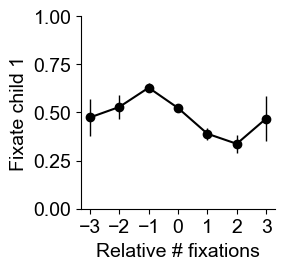

In [55]:
plt.figure(figsize = (2.5, 2.5))
df_grouped = df.groupby(['pid', 'relative_fixation_counts'])['child1_fixation_counts'].mean().reset_index()
df_summary = df_grouped.groupby(['relative_fixation_counts'])['child1_fixation_counts'].agg(['mean', 'std', 'count']).reset_index()
df_summary['se'] = df_summary['std'] / np.sqrt(df_summary['count'])
plt.errorbar(df_summary['relative_fixation_counts'], df_summary['mean'], yerr = df_summary['se'], fmt = 'o-', color = 'black', ecolor = 'black', elinewidth = 1, capsize = 0)
plt.xticks(range(-3, 4, 1))
plt.ylim((0, 1))
plt.xlabel('Relative # fixations')
plt.ylabel('Fixate child 1')
plt.show()

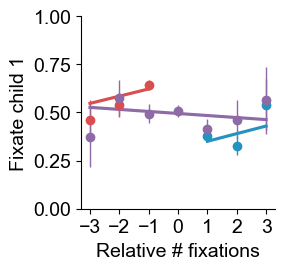

In [56]:
plt.figure(figsize = (2.5, 2.5))
colors = ['#2493BF', '#D94E4E', '#8E6AA6']
df_grouped = df.groupby(['pid', 'seen_groups', 'relative_fixation_counts'])['child1_fixation_counts'].mean().reset_index()
df_summary = df_grouped.groupby(['seen_groups', 'relative_fixation_counts'])['child1_fixation_counts'].agg(['mean', 'std', 'count']).reset_index()
df_summary['se'] = df_summary['std'] / np.sqrt(df_summary['count'])
for i, group in enumerate(['first', 'second', 'both']):
    df_filtered = df_summary[df_summary['seen_groups'] == group]
    plt.errorbar(df_filtered['relative_fixation_counts'], df_filtered['mean'], yerr = df_filtered['se'], fmt = 'o', color = colors[i], ecolor = colors[i], elinewidth = 1, capsize = 0)
for i, group in enumerate(['first', 'second', 'both']):
    df_filtered = df[df['seen_groups'] == group]
    sns.regplot(data = df_filtered, x = 'relative_fixation_counts', y = 'child1_fixation_counts', ci = False, scatter = False, color = colors[i])

plt.xticks(range(-3, 4, 1))
plt.ylim((0, 1))
plt.xlabel('Relative # fixations')
plt.ylabel('Fixate child 1')
plt.show()

## Switching policy

In [ ]:
dfs = []

for pid, data_subj in enumerate(data):

    jump_depths_subj = []
    jump_depths_baseline_subj = []
    jump_seens_subj = []

    for i in range(len(data_subj['pids'])):
        child_dict_ep = data_subj['child_dicts'][i]
        parent_dict_ep = data_subj['parent_dicts'][i]
        depths_ep = data_subj['depths'][i]
        fixation_seq_ep = data_subj['fixation_seqs'][i]
        # root_node_ep = data_subj['root_nodes'][i]

        # initialize node mask
        node_mask_ep = np.zeros((11,))
        # node_mask_ep[root_node_ep] = 1

        for node, node_next in list(zip(fixation_seq_ep, fixation_seq_ep[1:])):
            # update node mask
            node_mask_ep[node] = 1

            # if next node is a jump
            if relationship(child_dict_ep, node, node_next) != 'child':
                # append jump depth
                jump_depths_subj.append(depths_ep[node_next])

                # append seen groups
                if node_mask_ep[node_next] == 0:
                    jump_seens_subj.append('unseen')
                elif node_mask_ep[node_next] == 1:
                    jump_seens_subj.append('seen')

                # initialize non-child nodes
                jump_nodes_ep = np.arange(11)

                # exclude the node itself
                jump_nodes_ep = jump_nodes_ep[jump_nodes_ep != node]

                # exclude children if it has children
                if node in child_dict_ep.keys():
                    children = child_dict_ep[node]
                    jump_nodes_ep = jump_nodes_ep[(jump_nodes_ep != children[0]) & (jump_nodes_ep != children[1])]

                # randomly choose a jump node
                jump_node_random = random.choice(jump_nodes_ep)
                jump_depths_baseline_subj.append(depths_ep[jump_node_random])

    df_subj = pd.DataFrame({
        'jump_depths': jump_depths_subj,
        'jump_depths_baseline': jump_depths_baseline_subj,
        'jump_seens': jump_seens_subj,
    })
    df_subj['pid'] = pid
    dfs.append(df_subj)

df = pd.concat(dfs)

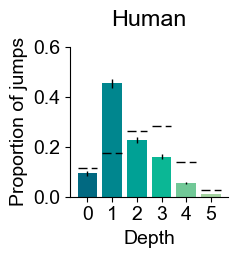

In [58]:
df_grouped = df.groupby(['pid', 'jump_depths']).size().reset_index(name = 'counts')
df_grouped['proportions'] = df_grouped.groupby('pid')['counts'].transform(lambda x: x / x.sum())
df_summary = df_grouped.groupby(['jump_depths'])['proportions'].agg(['mean', 'std', 'count']).reset_index()
df_summary['se'] = df_summary['std'] / np.sqrt(df_summary['count'])

df_grouped_baseline = df.groupby(['pid', 'jump_depths_baseline']).size().reset_index(name = 'counts')
df_grouped_baseline['proportions'] = df_grouped_baseline.groupby('pid')['counts'].transform(lambda x: x / x.sum())
df_summary_baseline = df_grouped_baseline.groupby(['jump_depths_baseline'])['proportions'].agg(['mean', 'std', 'count']).reset_index()

colors = ['#016981', '#00868E', '#00A195', '#0BB795', '#71C897', '#A3D2A0']
plt.figure(figsize = (2.6, 2.8))
bars = plt.bar(x = df_summary['jump_depths'], height = df_summary['mean'], color = colors)
plt.errorbar(df_summary['jump_depths'], df_summary['mean'], yerr = df_summary['se'], fmt = 'none', color = 'black', ecolor = 'black', elinewidth = 1, capsize = 0)
for j, bar in enumerate(bars):
    bar_height = df_summary_baseline['mean'][j] #bar.get_height()
    plt.hlines(y = bar_height, xmin = bar.get_x(), xmax = bar.get_x() + bar.get_width(), color = 'black', linestyle = (0, (6.5, 3.)), linewidth = 1)
plt.xticks(np.arange(0, 6))
plt.ylim((0, 0.6))
plt.xlabel('Depth')
plt.ylabel('Proportion of jumps')
plt.title('Human', pad = 15)
plt.tight_layout()
plt.savefig('figures/p_jump.pdf', bbox_inches = 'tight')

## Frontier policy

In [59]:
dfs = []

for pid, data_subj in enumerate(data):

    cum_points_subj = []
    frontier_fixation_counts_subj = []

    for i in range(len(data_subj['pids'])):
        child_dict_ep = data_subj['child_dicts'][i]
        root_node_ep = data_subj['root_nodes'][i]
        points_ep = data_subj['points'][i]
        cum_points_ep = data_subj['cum_points'][i]
        depths_ep = data_subj['depths'][i]
        fixation_seq_ep = data_subj['fixation_seqs'][i]

        # initialize frontier nodes
        frontier = np.array(child_dict_ep[root_node_ep])
    
        for node in fixation_seq_ep:
            # if the fixation is in frontier
            if node in frontier:
                # if both frontier nodes have been explored
                if (child_dict_ep[root_node_ep][0] not in frontier and child_dict_ep[root_node_ep][1] not in frontier):
                    # loop through frontier
                    for frontier_node in frontier:
                        # append cumulative point *leading to that node*
                        cum_points_subj.append(cum_points_ep[frontier_node] - points_ep[frontier_node])

                        # append if the frontier is the fixated node
                        frontier_fixation_counts_subj.append(int(frontier_node == node))
                
                # update frontier
                frontier = np.delete(frontier, np.where(frontier == node)[0])
                if node in child_dict_ep.keys():
                    frontier = np.append(frontier, child_dict_ep[node])

    df_subj = pd.DataFrame({
        'cum_points': cum_points_subj,
        'frontier_fixation_counts': frontier_fixation_counts_subj,
    })
    df_subj['pid'] = pid
    dfs.append(df_subj)

df = pd.concat(dfs)
df = df[(df['cum_points'] != 0) & (df['cum_points'] >= -20) & (df['cum_points'] <= 20)]

                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: frontier_fixation_counts
No. Observations: 15545   Method:             ML                      
No. Groups:       28      Scale:              0.2249                  
Min. group size:  17      Log-Likelihood:     -10470.8465             
Max. group size:  998     Converged:          Yes                     
Mean group size:  555.2                                               
-------------------------------------------------------------------------
                 Coef.    Std.Err.      z       P>|z|    [0.025    0.975]
-------------------------------------------------------------------------
Intercept        0.344       0.006    57.380    0.000     0.333     0.356
cum_points       0.004       0.001     6.454    0.000     0.003     0.006
Group Var        0.000       0.001                                       



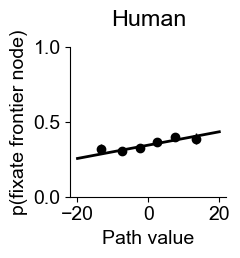

In [ ]:
plt.figure(figsize = (2.6, 2.8))
bins = [-100, -9.5, -4.5, 0, 4.5, 9.5, 100]
labels = [-13.5, -7.5, -2.5, 2.5, 7.5, 13.5]
df['group'] = pd.cut(df['cum_points'], bins = bins, labels = labels, include_lowest = False, right = False)
# df['group'] = df['cum_points']
df_grouped = df.groupby(['pid', 'group'])['frontier_fixation_counts'].mean().reset_index()
df_summary = df_grouped.groupby(['group'])['frontier_fixation_counts'].agg(['mean', 'std', 'count']).reset_index()
df_summary['se'] = df_summary['std'] / np.sqrt(df_summary['count'])
plt.errorbar(df_summary['group'], df_summary['mean'], yerr = df_summary['se'], fmt = 'o', color = 'black', ecolor = 'black', elinewidth = 1, capsize = 0)

model = smf.mixedlm('frontier_fixation_counts ~ cum_points', df, groups = df['pid'])
result = model.fit(reml = False)
print(result.summary())
x_pred = np.linspace(-20, 20, 200)
df_pred = pd.DataFrame({'cum_points': x_pred})
df_pred['frontier_fixation_counts'] = result.predict(df_pred)
plt.plot(df_pred['cum_points'], df_pred['frontier_fixation_counts'], color = 'k', linewidth = 2)

plt.ylim((0, 1))
plt.xlabel('Path value')
plt.ylabel('p(fixate frontier node)')
plt.title('Human', pad = 15)
plt.tight_layout()
# plt.show()
plt.savefig('figures/p_frontier.pdf', bbox_inches = 'tight')

In [5]:
num_nodes = 11

dfs = []

for pid, data_subj in enumerate(data):

    chosens_subj = []
    points_subj = []
    fixation_counts_chosen_subj = []

    for i in range(len(data_subj['pids'])):
        root_node_ep = data_subj['root_nodes'][i]
        points_ep = data_subj['points'][i]
        fixation_seq_ep = data_subj['fixation_seqs'][i]
        decision_seq_ep = data_subj['decision_seqs'][i]

        for node in range(num_nodes):
            # if not root node
            if node != root_node_ep:
                # append if the node is chosen
                chosens_subj.append(int(node in decision_seq_ep))

                # append point in the node
                points_subj.append(points_ep[node])

                # append fixation count of the node
                fixation_counts_chosen_subj.append(np.sum(fixation_seq_ep.count(node)))

    # fixation_clip = 3
    df_subj = pd.DataFrame({
        'chosens': chosens_subj,
        'points': points_subj,
        'fixation_counts_chosen': fixation_counts_chosen_subj
    })

    df_subj['pid'] = pid
    dfs.append(df_subj)

df = pd.concat(dfs)

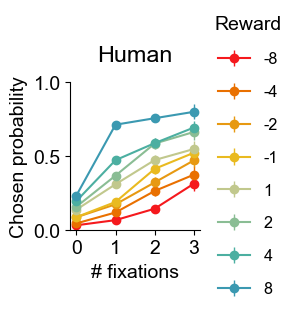

In [10]:
df_filtered = df[df['fixation_counts_chosen'] <= 3]

df_grouped = df_filtered.groupby(['pid', 'fixation_counts_chosen', 'points'])['chosens'].mean().reset_index()
df_summary = df_grouped.groupby(['fixation_counts_chosen', 'points'])['chosens'].agg(['mean', 'std', 'count']).reset_index()
df_summary['se'] = df_summary['std'] / np.sqrt(df_summary['count'])

colors = ['#F5191D', '#E97000', '#E79912', '#E9BA20', '#C1C88D', '#8ABD94', '#4CAFA1', '#3B99B1']
plt.figure(figsize = (3.2, 2.8))
for i, point in enumerate(df_summary['points'].unique()):
    df_point = df_summary[df_summary['points'] == point]
    plt.errorbar(df_point['fixation_counts_chosen'], df_point['mean'], yerr = df_point['se'], fmt = 'o-', label = point, color = colors[i], ecolor = colors[i], elinewidth = 1, capsize = 0)
plt.xticks(np.arange(4))
plt.ylim((0, 1))
plt.xlabel('# fixations')
plt.ylabel('Chosen probability')
plt.title('Human', pad = 15)
plt.legend(title = 'Reward', bbox_to_anchor = (1, 0.5), loc = 'center left', frameon = False, fontsize = 'small', labelspacing=1.1)
plt.tight_layout()
# plt.show()
plt.savefig('figures/p_evidence_accumulation_q.pdf', bbox_inches='tight')

             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: refixation_counts
No. Observations: 28538   Method:             ML               
No. Groups:       28      Scale:              0.1218           
Min. group size:  31      Log-Likelihood:     -10469.9151      
Max. group size:  3218    Converged:          Yes              
Mean group size:  1019.2                                       
-----------------------------------------------------------------
              Coef.   Std.Err.     z      P>|z|   [0.025   0.975]
-----------------------------------------------------------------
Intercept     0.153      0.006   23.778   0.000    0.140    0.166
q_values      0.006      0.000   14.354   0.000    0.005    0.006
Group Var     0.001      0.001                                   



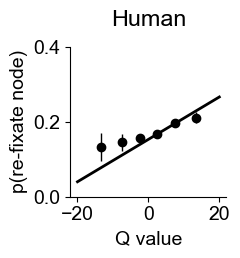

In [63]:
dfs = []

for pid, data_subj in enumerate(data):

    refixation_counts_subj = []
    q_values_subj = []

    for i in range(len(data_subj['pids'])):
        child_dict_ep = data_subj['child_dicts'][i]
        root_node_ep = data_subj['root_nodes'][i]
        points_ep = data_subj['points'][i]
        fixation_seq_ep = data_subj['fixation_seqs'][i]

        # initialize node mask
        node_mask_ep = np.zeros((11))
        node_mask_ep[root_node_ep] = 1.

        for node in fixation_seq_ep:
            # if the fixation is a refixation (already visited)
            if node_mask_ep[node] == 1:
                # compute q values using only revealed points
                q_values_ep = get_q_values(child_dict_ep, points_ep * node_mask_ep)

                # loop through all previously visited nodes
                visited_nodes = np.where(node_mask_ep == 1)[0]
                for visited_node in visited_nodes:
                    # append q value of this visited node
                    q_values_subj.append(q_values_ep[visited_node])

                    # append whether this visited node was the one refixated
                    refixation_counts_subj.append(int(visited_node == node))

            # update node mask after the check
            node_mask_ep[node] = 1.

    df_subj = pd.DataFrame({
        'q_values': q_values_subj,
        'refixation_counts': refixation_counts_subj,
    })
    df_subj['pid'] = pid
    dfs.append(df_subj)

df = pd.concat(dfs)
df = df[(df['q_values'] >= -20) & (df['q_values'] <= 20) & (df['q_values'] != 0)]

plt.figure(figsize = (2.6, 2.8))
bins = [-100, -9.5, -4.5, 0, 4.5, 9.5, 100]
labels = [-13.5, -7.5, -2.5, 2.5, 7.5, 13.5]
df['group'] = pd.cut(df['q_values'], bins=bins, labels=labels, include_lowest=False, right=False)
# df['group'] = df['q_values']
df_grouped = df.groupby(['pid', 'group'])['refixation_counts'].mean().reset_index()
df_summary = df_grouped.groupby(['group'])['refixation_counts'].agg(['mean', 'std', 'count']).reset_index()
df_summary['se'] = df_summary['std'] / np.sqrt(df_summary['count'])
plt.errorbar(df_summary['group'], df_summary['mean'], yerr=df_summary['se'], fmt='o', color='black', ecolor='black', elinewidth=1, capsize=0)

model = smf.mixedlm('refixation_counts ~ q_values', df, groups=df['pid'])
result = model.fit(reml=False)
print(result.summary())
x_pred = np.linspace(-20, 20, 200)
df_pred = pd.DataFrame({'q_values': x_pred})
df_pred['refixation_counts'] = result.predict(df_pred)
plt.plot(df_pred['q_values'], df_pred['refixation_counts'], color='k', linewidth=2)

plt.ylim((0, 0.4))
plt.xlabel('Q value')
plt.ylabel('p(re-fixate node)')
plt.title('Human', pad=15)
plt.tight_layout()
plt.savefig('figures/p_refixation_q.pdf', bbox_inches='tight')